In [1]:
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFTGate
from qiskit import transpile
from qiskit.visualization import plot_histogram
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt

In [2]:
#load image
def load_image(filename):
    im = Image.open(filename,'r')
    im = im.convert('L') #convert to grayscale
    return np.array(im)

In [3]:
#encode image into quantum state
def encode_image(filename, n_qubits):
    #open image file in greyscale and form normalized array
    pixel_value_array = load_image(filename).flatten()
    
    #Normalize the pixel values
    norm = np.linalg.norm(pixel_value_array)
    norm_array = pixel_value_array/norm


    #translate normalized array into qubits by assigning each pixel value to the amplitude of a quantum state
    
    qc = QuantumCircuit(n_qubits)
    qc.initialize(norm_array, qc.qubits)
    return qc,norm_array
    

In [52]:
import numpy as np
from qiskit import transpile
from qiskit_aer import AerSimulator

def measure_image(qc, original_n_qubits, shots=10000):
    """
    Measures a QPIE image circuit. Automatically handles standard circuits 
    as well as circuits with added ancilla qubits for filtering.
    """
    # 1. Execute the circuit
    # Only append measure_all if the circuit doesn't already have measurements
    if not qc.cregs:
        qc.measure_all()
        
    aer_sim = AerSimulator()
    t_qc = transpile(qc, aer_sim, optimization_level=3)
    result = aer_sim.run(t_qc, shots=shots).result()
    counts = result.get_counts()
    num_ancillas = qc.num_qubits - original_n_qubits
    success_flag = '1' * num_ancillas

    # --- DIAGNOSTIC PRINT ---
    if num_ancillas > 0:
        successful_shots = sum([count for state, count in counts.items() 
                                if state.replace(' ', '')[:num_ancillas] == success_flag])
        print(f"--- FILTER DIAGNOSTICS ---")
        print(f"Total Shots Fired: {shots}")
        print(f"Successful '11' Measurements: {successful_shots}")
        print(f"Retention Rate: {(successful_shots / shots) * 100:.2f}%")
        if successful_shots < 2000:
            print("WARNING: Too few successful shots to reconstruct a clean image. Image will be extremely noisy.")
        print(f"--------------------------")

    # 2. Construct measured image array based ONLY on the original image size
    measured_arr = np.zeros(2**original_n_qubits, dtype=float)

    # Calculate how many ancilla qubits were added (e.g., by the Gaussian filter)
    num_ancillas = qc.num_qubits - original_n_qubits
    
    # We only want states where the ancillas measured as '1' (success flag)
    success_flag = '1' * num_ancillas

    # 3. Parse the counts dictionary dynamically
    for state, count in counts.items():
        # Remove spaces in case Qiskit formats the output with registers
        state = state.replace(' ', '')
        
        # In Qiskit, qubits added last (the ancillas) are the leftmost bits
        ancilla_bits = state[:num_ancillas] if num_ancillas > 0 else ''
        img_bits = state[num_ancillas:]

        # Record amplitude if it's a raw image, OR if the filter succeeded
        if ancilla_bits == success_flag or num_ancillas == 0:
            idx = int(img_bits, 2)
            measured_arr[idx] = count / shots

    # Convert probability to amplitude
    measured_arr = np.sqrt(measured_arr)

    # 4. Convert back into RGB (0-255 scaling)
    max_val = np.max(measured_arr)
    if max_val > 0: # Prevent division by zero if no shots succeeded
        measured_arr = (measured_arr * 255) / max_val
        
    # Dynamically reshape into a square grid
    size = int(np.sqrt(2**original_n_qubits))
    measured_arr = measured_arr.reshape((size, size))
    
    return measured_arr

In [49]:
def apply_gaussian_filter(qc, sigma=1.5):
    n_img_qubits = qc.num_qubits
    half_n = n_img_qubits // 2
    
    anc_reg = QuantumRegister(2, 'anc')
    qc.add_register(anc_reg)
    
    # FIX 1: Remove approximation_degree for 5-qubit registers
    qft_gate = QFT(half_n, do_swaps=True).to_gate(label=f"QFT_{half_n}")
    
    qc.append(qft_gate, range(half_n))
    qc.append(qft_gate, range(half_n, n_img_qubits))
    
    # FIX 2: Expand the frequency window to smooth the cutoff
    target_k_values = [0, 1, 2, 3, 4, -1, -2, -3, -4]
    target_frequencies = {}
    
    for k in target_k_values:
        val = k if k >= 0 else (2**half_n) + k
        bin_state = format(val, f'0{half_n}b')
        target_frequencies[bin_state] = k

    def apply_1d_filter(target_reg_start, anc_idx):
        for bin_state, k in target_frequencies.items():
            weight = np.exp(-(k**2) / (2 * sigma**2))
            # Clamp weight to avoid domain errors in arcsin
            weight = max(0.0, min(1.0, weight)) 
            theta = 2 * np.arcsin(weight)
            
            mcry = RYGate(theta).control(half_n, ctrl_state=bin_state)
            qubit_targets = list(range(target_reg_start, target_reg_start + half_n)) + [n_img_qubits + anc_idx]
            qc.append(mcry, qubit_targets)

    apply_1d_filter(0, 0)
    apply_1d_filter(half_n, 1)
    
    iqft_gate = qft_gate.inverse()
    qc.append(iqft_gate, range(half_n))
    qc.append(iqft_gate, range(half_n, n_img_qubits))
    
    return qc

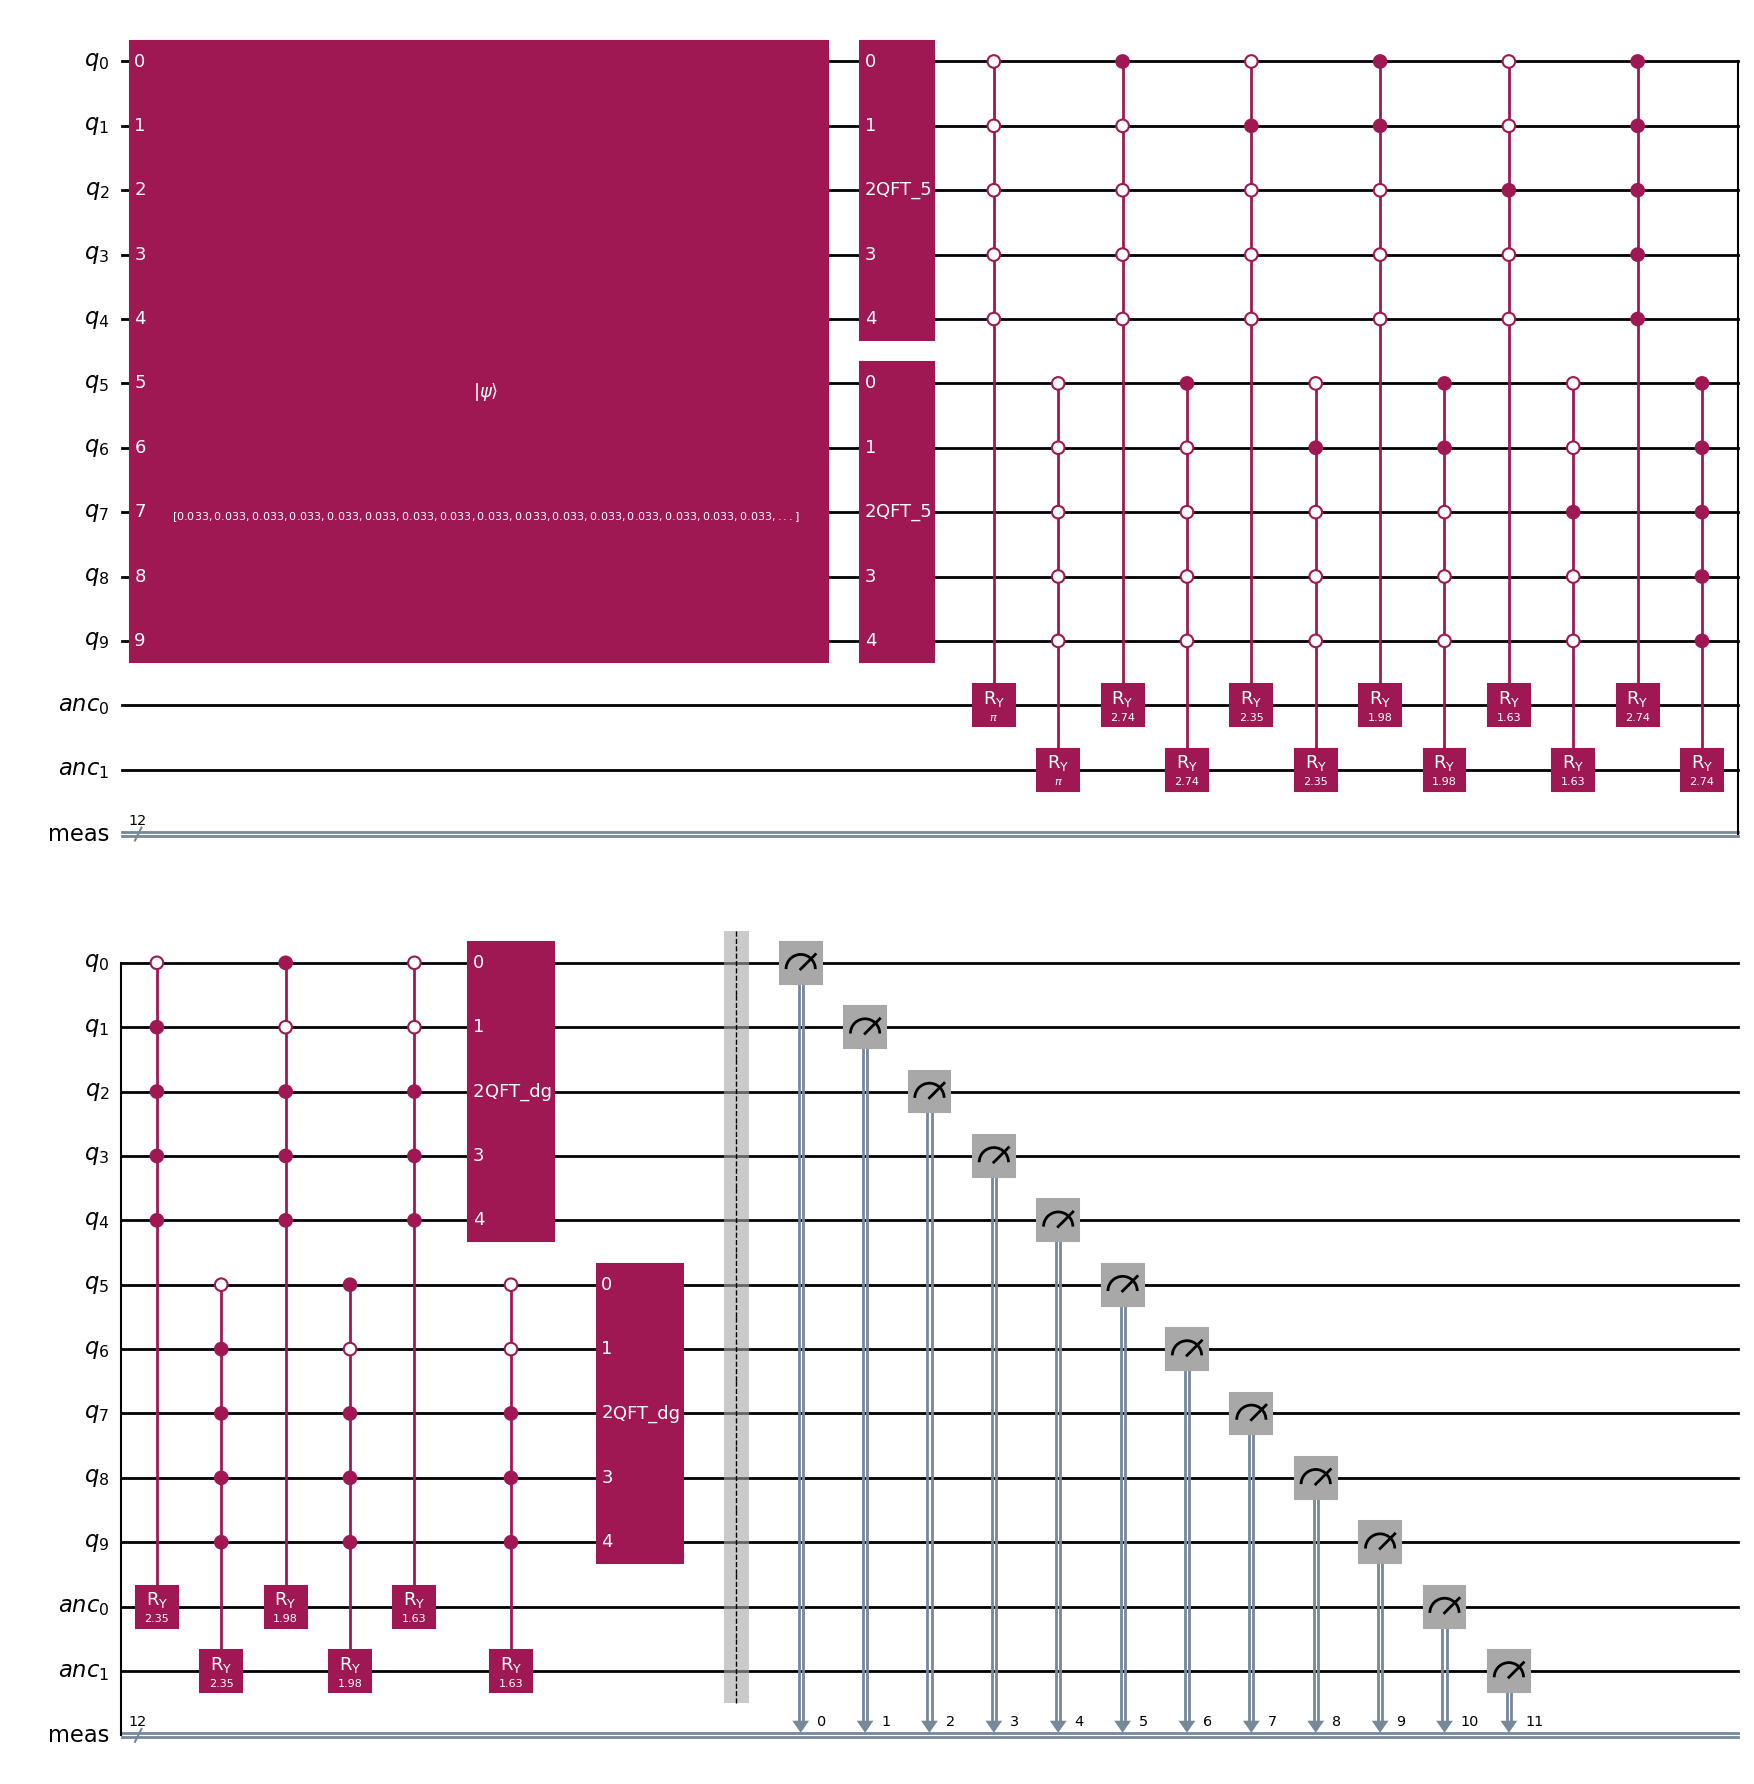

In [59]:
qc.draw('mpl')

C:\Users\benz5\AppData\Local\Temp\ipykernel_2132\3279273406.py:9: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_gate = QFT(half_n, do_swaps=True).to_gate(label=f"QFT_{half_n}")


--- FILTER DIAGNOSTICS ---
Total Shots Fired: 100000
Successful '11' Measurements: 91069
Retention Rate: 91.07%
--------------------------


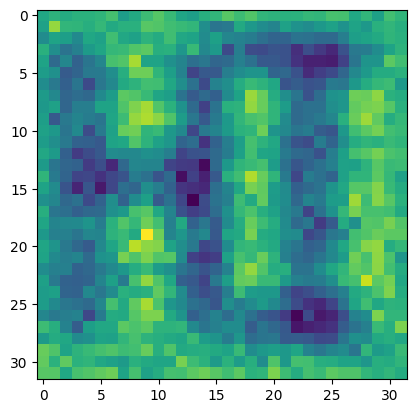

In [60]:
qc,norm_arr = encode_image('HI_32.png', 10)
qc = apply_gaussian_filter(qc, sigma=5)


blurred_image_array = measure_image(qc, original_n_qubits=10, shots=100000)

plt.imshow(blurred_image_array)

In [5]:
def semi_classical_QFT(n,qc):
    qr = QuantumRegister(n, 'q')
    cr = ClassicalRegister(n, 'c')
    
    qc.x(0)
    qc.barrier()
    
    for i in range(n - 1, -1, -1):
        qc.h(qr[i])
        qc.measure(qr[i], cr[i])
        
        for j in range(i - 1, -1, -1):
            phase_angle = np.pi / (2 ** (i - j))
            
            # Modern Qiskit 1.0+ syntax for classically conditioned gates
            with qc.if_test((cr[i], 1)):
                qc.p(phase_angle, qr[j])
                        
        qc.barrier()
        
    return qc

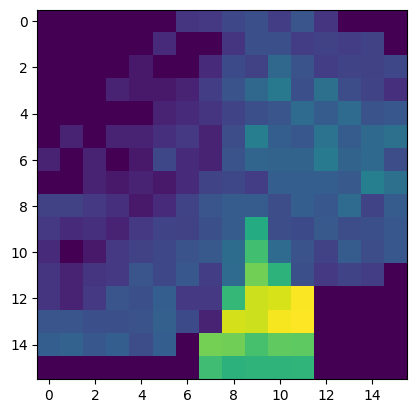

In [13]:
#try to flip image

c = 1e-8 #to avoid log(0) error when plotting
qc,norm_arr = encode_image('cake-large.png', 8)

qc.x(range(8))
measured_arr = measure_image(qc, shots = 5000)

plt.imshow(measured_arr)




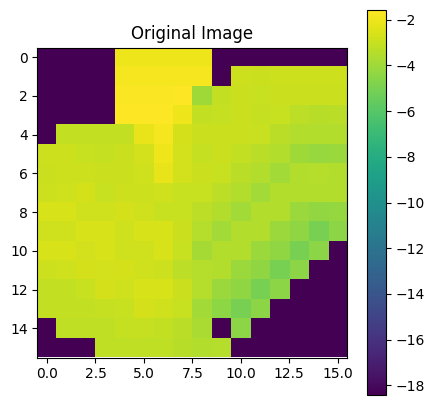

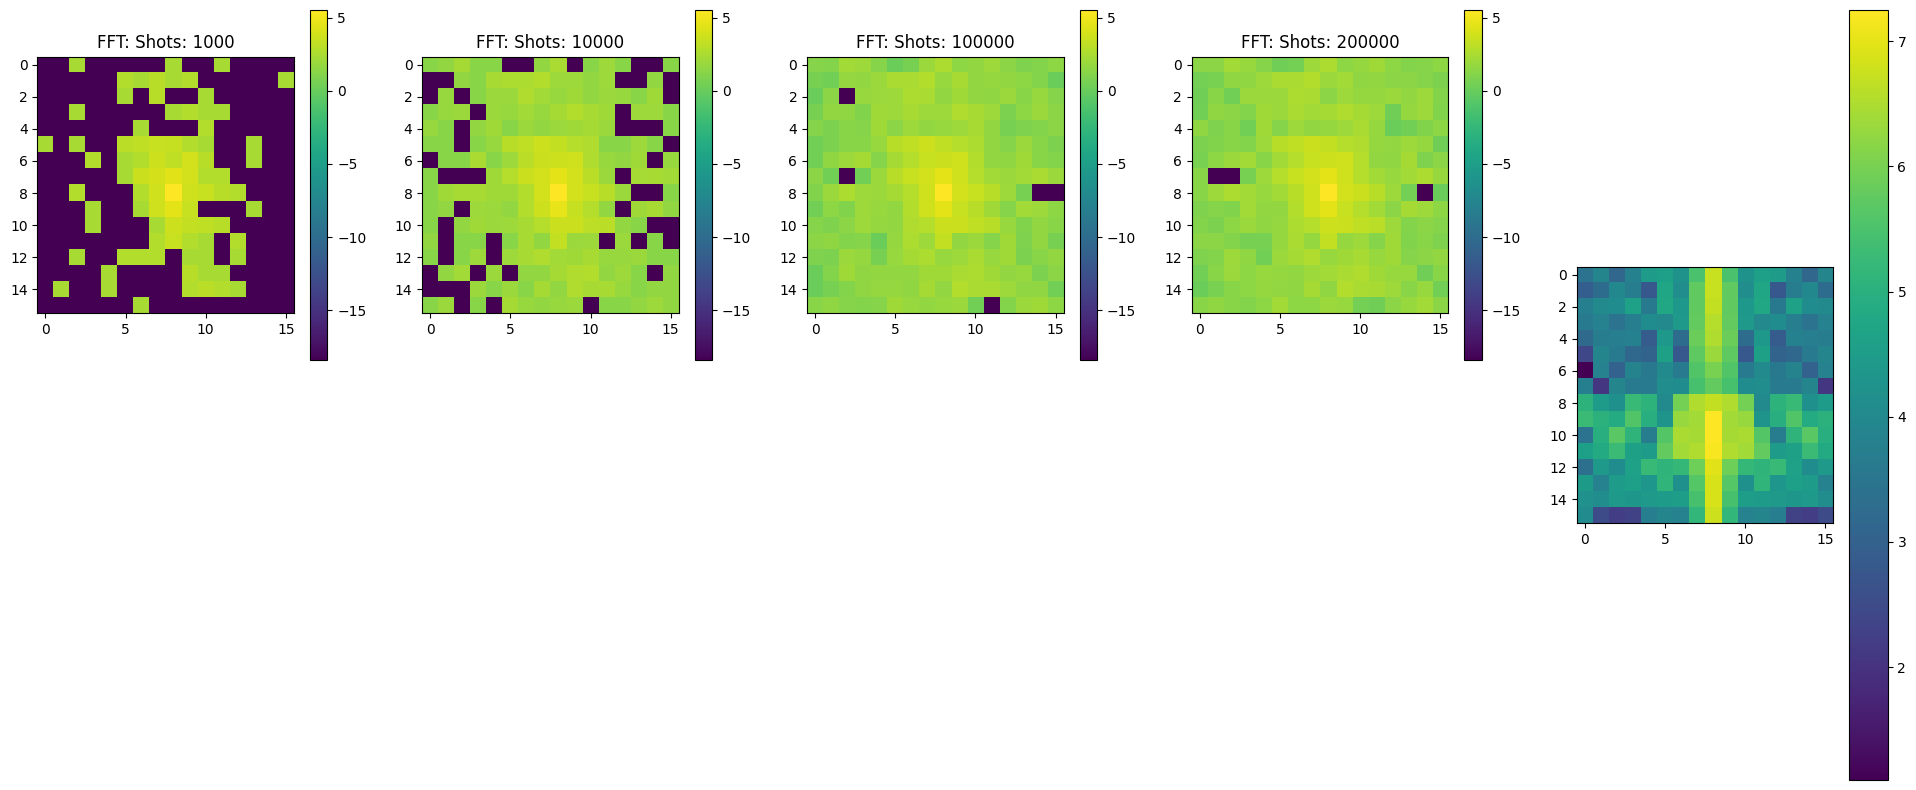

In [9]:
#QFT on image
c = 1e-8 #to avoid log(0) error when plotting
qc,norm_arr = encode_image('cake-large.png', 8)
qc.append(QFTGate(8), qc.qubits)
# display the circuit
shots = np.array([1000, 10000, 100000, 200000])
plt.figure(figsize=(5, 5))
plt.imshow(np.log(norm_arr.reshape((16,16)) + c))
plt.colorbar()
plt.title('Original Image')
plt.show()

plt.figure(figsize=(24, 10))
'''
for i in range(len(shots)):
    qc,norm_arr = encode_image('cake-large.png', 8)
    qc = semi_classical_QFT(8,qc)
    measured_arr = measure_image(qc, shots = shots[i])
    shifted_image = np.fft.fftshift(measured_arr)
    plt.subplot(2, len(shots)+1, len(shots) + i + 1)
    plt.imshow(np.log(shifted_image + c))
    plt.colorbar()
    plt.title(f'FFT: Shots: {shots[i]}');'''

for i in range(len(shots)):
    measured_arr = measure_image(qc, shots = shots[i])
    shifted_image = np.fft.fftshift(measured_arr)
    plt.subplot(2, len(shots)+1, i + 1)
    plt.imshow(np.log(shifted_image + c))
    plt.colorbar()
    plt.title(f'FFT: Shots: {shots[i]}')
    
    qc,norm_arr = encode_image('cake-large.png', 8)
    qc.append(QFTGate(8), qc.qubits)
    

#classical FT
im = load_image('cake-large.png')
f_transform = np.fft.fft(im)
f_shift = np.fft.fftshift(f_transform)
magnitude_spectrum = np.log(np.abs(f_shift) + c)
plt.subplot(1, len(shots) + 1, len(shots) + 1)
plt.imshow(magnitude_spectrum)
plt.colorbar()
plt.show()

1. fourier space
2. putting into the program + processing
3. limit to qubits
4. how to correlate the data between the opposite sides of the spectrum
5. More examples - real data

C:\Users\benz5\quantum_computing\.venv\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


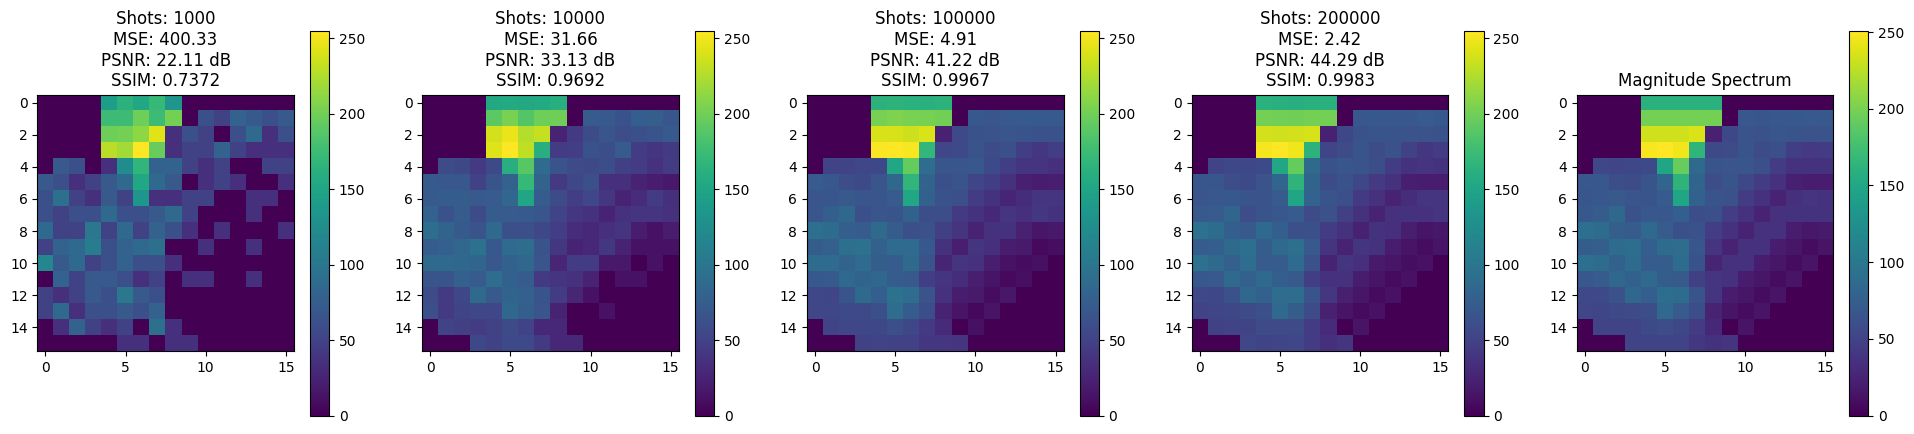

In [11]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# transform to the spatial domain
# inverse QFT
inverse_f_transform = np.fft.ifft(f_transform)
magnitude_spectrum = np.abs(inverse_f_transform)
plt.figure(figsize=(24, 5))
plt.subplot(1, len(shots) + 1, len(shots) + 1)
plt.imshow(magnitude_spectrum)
plt.colorbar()
plt.title('Magnitude Spectrum')
for i in range(len(shots)):
    qc,norm_arr = encode_image('cake-large.png', 8)
    qc.append(QFTGate(8), qc.qubits)
    qc.append(QFTGate(8).inverse(), qc.qubits)
    measured_arr = measure_image(qc, shots = shots[i])
    # calculate the mean squared error
    mse = np.mean((measured_arr - magnitude_spectrum) ** 2)
    psnr_val = 10 * np.log10((255 ** 2) / mse)
    ssim_val = ssim(magnitude_spectrum, measured_arr, data_range=255)

    # shifted_image = np.fft.fftshift(measured_arr)
    plt.subplot(1, len(shots)+1, i + 1)
    plt.imshow(measured_arr)
    plt.colorbar()
    plt.title(f"Shots: {shots[i]}\n"
                 f"MSE: {mse:.2f}\n"
                 f"PSNR: {psnr_val:.2f} dB\n"
                 f"SSIM: {ssim_val:.4f}")
        

plt.show()

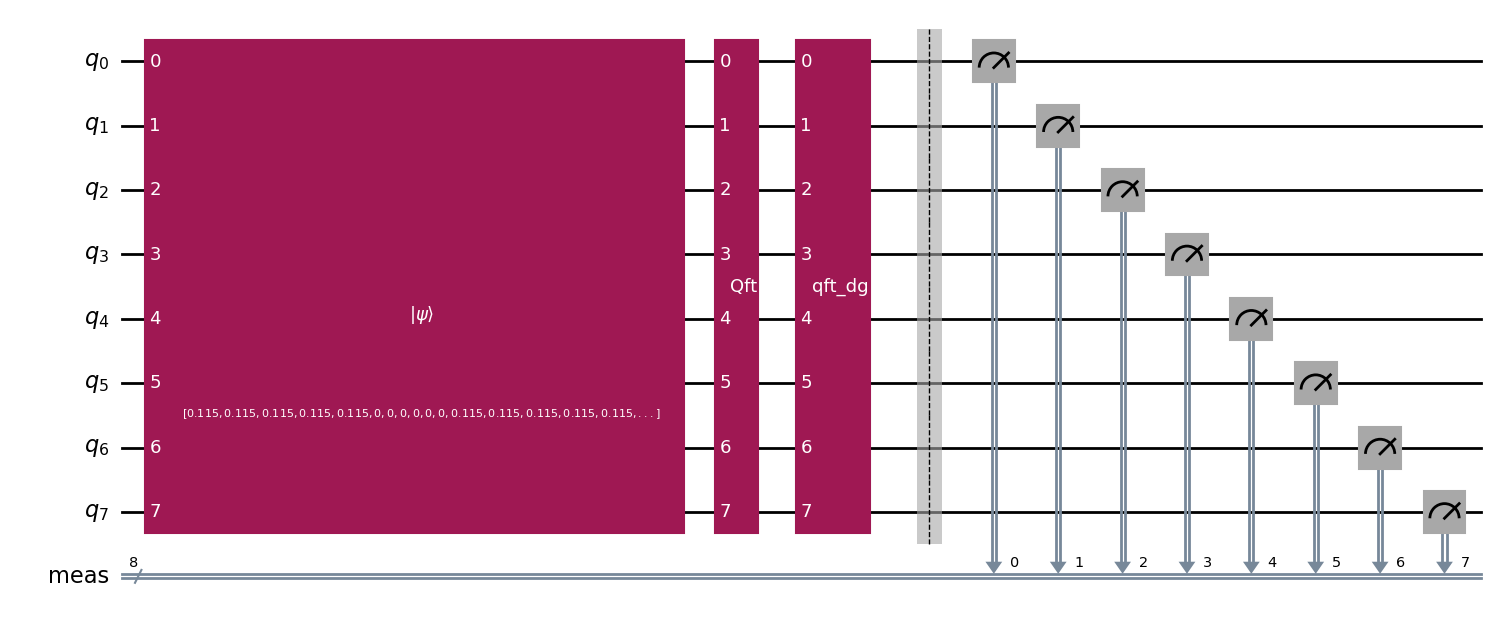

In [ ]:
qc.draw('mpl')

### Quantum advantage
Less time, less energy, more accurate results (mean squared error?).
Scalability, compilability, connectivity, robustness, parallelizability.
https://arxiv.org/pdf/2303.02138

### Questions
1. Should we write down the circuits by hand from the simplest gates?

### Next steps
1. Make decoding.
2. Apply kernles in fourier domain.
3. Try colored images.
4. Measure quantum advantage.